In [ ]:
# Hosted D2L setup: fetch the exact helper module used to build this notebook.
from pathlib import Path
from urllib.request import urlretrieve
from importlib.metadata import PackageNotFoundError, version
import importlib.util, os, subprocess, sys

required = ['numpy', 'pandas', 'matplotlib', 'requests', 'scipy', 'pillow', 'regex', 'torch', 'torchvision']
imports = {'pillow': 'PIL'}
pinned = {}
fallbacks = {'torch': 'torch==2.11.0', 'torchvision': 'torchvision==0.26.0'}
device = os.environ.get("D2L_HOSTED_DEVICE", "auto").lower()
if device not in ("auto", "cpu", "gpu"):
    raise ValueError(f"Invalid D2L_HOSTED_DEVICE={device!r}")
if device == "auto":
    try:
        gpu = (Path("/dev/nvidia0").exists() or
               subprocess.run(["nvidia-smi", "-L"], capture_output=True,
                              timeout=5).returncode == 0)
    except (FileNotFoundError, subprocess.SubprocessError):
        gpu = False
else:
    gpu = device == "gpu"
if not gpu:
    os.environ.setdefault("CUDA_VISIBLE_DEVICES", "-1")
    os.environ.setdefault("JAX_PLATFORMS", "cpu")
tensorflow_version = None
if 'pytorch' in ("tensorflow", "jax"):
    try:
        tensorflow_version = version("tensorflow")
    except PackageNotFoundError:
        pass
# Colab's CPU image currently carries a CUDA-enabled TensorFlow wheel. Its
# first ordinary tensor operation probes CUDA and emits an error-level cuInit
# diagnostic. JAX notebooks also use TensorFlow for data loading, so overlay
# the matching CPU build in both CPU variants. Keep the provider's
# ``tensorflow`` distribution metadata: other preinstalled Colab packages
# depend on that distribution name, while both wheels expose the same module.
if not gpu and 'pytorch' in ("tensorflow", "jax"):
    try:
        tensorflow_cpu_version = version("tensorflow-cpu")
    except PackageNotFoundError:
        tensorflow_cpu_version = None
    if (tensorflow_version is not None and
            tensorflow_cpu_version != tensorflow_version):
        subprocess.check_call([
            sys.executable, "-m", "pip", "install", "-q", "--no-deps",
            f"tensorflow-cpu=={tensorflow_version}",
        ])
if "tf-keras" in fallbacks and tensorflow_version is not None:
    fallbacks["tf-keras"] = f"tf-keras=={tensorflow_version}"
missing = []
for package in required:
    if package in pinned:
        wanted, cpu_requirement, gpu_requirement, match = pinned[package]
        requirement = gpu_requirement if gpu else cpu_requirement
        try:
            installed = version(package)
        except PackageNotFoundError:
            installed = None
        actual = (installed.split("+", 1)[0]
                  if installed is not None and match == "public" else installed)
        if actual != wanted:
            missing.append(requirement)
    elif importlib.util.find_spec(imports.get(package, package)) is None:
        missing.append(fallbacks.get(package, package))
if missing:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", *missing])

mismatched = []
for package, (wanted, _, _, match) in pinned.items():
    try:
        installed = version(package)
    except PackageNotFoundError:
        installed = None
    actual = (installed.split("+", 1)[0]
              if installed is not None and match == "public" else installed)
    if actual != wanted:
        mismatched.append(f"{package}={installed!r} (expected {wanted})")
if mismatched:
    raise RuntimeError("Hosted runtime setup failed: " + ", ".join(mismatched))

root = Path(".d2l-hosted") / "8cd319b4f2187b6b29bb69603a96460fc325a975"
package = root / "d2l"
package.mkdir(parents=True, exist_ok=True)
base = "https://raw.githubusercontent.com/smolix/d2l-neu/8cd319b4f2187b6b29bb69603a96460fc325a975/d2l"
for name in ('__init__.py', 'torch.py'):
    target = package / name
    if not target.exists():
        urlretrieve(f"{base}/{name}", target)
if str(root.resolve()) not in sys.path:
    sys.path.insert(0, str(root.resolve()))
pythonpath = os.environ.get("PYTHONPATH", "").split(os.pathsep)
if str(root.resolve()) not in pythonpath:
    os.environ["PYTHONPATH"] = os.pathsep.join(
        [str(root.resolve()), *[entry for entry in pythonpath if entry]]
    )


# Scaling Up

Every method in this chapter was tuned by sweeping. In that section each
optimizer received a grid of learning rates and its best run spoke for it; in
that section we swept batch sizes the same way. On models that
train in seconds this is the right procedure. But the models that matter are
trained once: a frontier language model occupies thousands of accelerators
for months, and there is no grid search at that price. Its hyperparameters
still have to come from somewhere. The working answer across the industry is
to tune something small and *transfer* the result up.

This section is about when that transfer works. We first demonstrate that by
default it does not: the best learning rate of a model family is not a
property of the task but of the model's size, and it drifts as the network
widens. We then present the *maximal update parametrization* (muP), which
moves the width dependence out of the hyperparameters and into the model,
together with the two experiments practitioners use to verify it — a
*coordinate check* and a transfer sweep. We close by connecting the fix to
the update-norm story of that section and by surveying what production
training runs actually do, muP included but not alone.

In [1]:
%matplotlib inline
from d2l import torch as d2l
import math
import numpy as np
import torch
from torch import nn
from torch.nn import functional as F

## The Optimum Does Not Stay Put

### A Family of Widths

We want the smallest experiment with a genuine notion of "the same model,
scaled up". A multilayer perceptron on Fashion-MNIST provides it: three
hidden layers of width $n$, with $n$ running from 128 to 1,024. Every model
in the family computes the same kind of function; only the width differs.
Note where the width actually lives: the input matrix always has fan-in 784
and the output matrix always has fan-out 10, so it is the two square
$n \times n$ matrices in the middle whose dimensions both grow with scale.
That distinction is about to matter. Since we will train several dozen of
these models for a few hundred steps each, we keep the entire training set
resident on the accelerator as one flat tensor — 60,000 images make under
200 MB, and no data loader is worth its overhead here.

In [2]:
fashion = d2l.FashionMNIST()
device = d2l.try_gpu()
X = (fashion.train.data.float().reshape(-1, 784) / 255).to(device)
Y = fashion.train.targets.to(device)

The model family comes next. We spell the initialization out rather than
trust framework defaults, both because the two frameworks' defaults differ
and because the initialization is about to become part of the story: every
weight is Gaussian with variance $1/\text{fan-in}$, every bias zero. This is
*standard parametrization* (SP) — up to constants, what default initializers
do, and what the Xavier and He schemes of that section
prescribe. The optimizer lives in a method, `configure_adam`, so that a variant of
the class can override it later.

In [3]:
class MLP(nn.Module):
    """A three-hidden-layer ReLU network under standard parametrization."""
    def __init__(self, width):
        super().__init__()
        self.fc_in = nn.Linear(784, width)
        self.fc_h1 = nn.Linear(width, width)
        self.fc_h2 = nn.Linear(width, width)
        self.fc_out = nn.Linear(width, 10)
        for lin in (self.fc_in, self.fc_h1, self.fc_h2, self.fc_out):
            nn.init.normal_(lin.weight, std=lin.in_features ** -0.5)
            nn.init.zeros_(lin.bias)

    def features(self, X):
        h = F.relu(self.fc_h1(F.relu(self.fc_in(X))))
        return F.relu(self.fc_h2(h))

    def forward(self, X):
        return self.fc_out(self.features(X))

    def configure_adam(self, lr):
        return torch.optim.Adam(self.parameters(), lr)

The training harness is a step-counted loop in the style of
that section: 400 steps of Adam at batch size 512, roughly three
passes over the data, at a constant learning rate. Both frameworks draw the
same fixed sequence of minibatch indices, so a run is a deterministic
function of its width, parametrization, and learning rate. The score of a
run is its cross-entropy over the whole training set after the last step; a
diverged run is capped at 2.5, slightly above the loss of random guessing
($\ln 10 \approx 2.3$).

In [4]:
def train_step(model, optimizer, Xb, Yb):
    loss = F.cross_entropy(model(Xb), Yb)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    return loss.detach()

def train_mlp(arch, width, lr, num_steps=400, batch_size=512):
    torch.manual_seed(0)
    model = arch(width).to(device)
    optimizer = model.configure_adam(lr)
    idx = np.random.default_rng(0).integers(0, X.shape[0],
                                            (num_steps, batch_size))
    for i in idx:
        train_step(model, optimizer, X[i], Y[i])
    with torch.no_grad():
        v = float(F.cross_entropy(model(X), Y))
    return min(v, 2.5) if math.isfinite(v) else 2.5

### The Sweep

Now the experiment. Four widths, eight learning rates spaced by factors of
two, one short run each — 32 runs, about a minute on one GPU. This is
exactly the procedure a careful practitioner would use to tune the small
model before scaling it up, so whatever it shows about the small model's
optimum is what transfer would carry to the large one.

width  128: best lr 7.8e-03
width  256: best lr 2.0e-03
width  512: best lr 2.0e-03
width 1024: best lr 9.8e-04


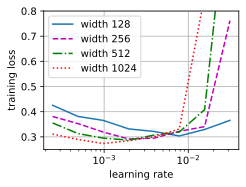

In [5]:
widths = [128, 256, 512, 1024]
lrs = [2 ** k for k in range(-12, -4)]
sp_loss = {w: [train_mlp(MLP, w, lr) for lr in lrs] for w in widths}
for w in widths:
    print(f'width {w:4d}: best lr {min(zip(sp_loss[w], lrs))[1]:.1e}')
d2l.plot(lrs, [sp_loss[w] for w in widths], 'learning rate',
         'training loss', xscale='log', ylim=[0.25, 0.8],
         legend=[f'width {w}' for w in widths])

Each width traces a U: too small a learning rate undertrains, too large
destabilizes — the widest curves climb off the top of the chart on the
right, where the capped runs sit. But the U's do not line up. The minimum
slides steadily left as the network widens: in these runs the best learning
rate at width 1,024 is about eight times smaller than at width 128, and the
drift continues at larger widths [@Yang.Hu.Babuschkin.ea.2022]. Two
readings follow. First, at its own optimum, the wider model always at least
matches the narrower one, so width costs nothing but compute. Second, the
narrow model's optimum is a bad setting for the wide one and vice versa:
tune at width 128, reuse the setting at width 1,024, and the wide model
lands well up the unstable branch of its U. The best learning rate is not a
property of the task. It is a property of the model size, and transferring
it naively means transferring a mistake.

### Why It Moves

The drift has a mechanism, and it is worth seeing exactly, because the fix
consists of undoing it layer by layer. Consider a hidden weight matrix
$\mathbf{W} \in \mathbb{R}^{n \times n}$ receiving activations $\mathbf{h}$
with entries of typical size $\overline{|h|}$. For a single example its
gradient is an outer
product, $\mathbf{g} = \boldsymbol{\delta} \mathbf{h}^\top$, where
$\boldsymbol{\delta}$ is the backpropagated error. On the very first step
Adam's ratio $\hat{\mathbf{m}}/\sqrt{\hat{\mathbf{v}}}$ equals
$\operatorname{sign}(\mathbf{g})$ exactly — the sign-descent connection of
that section, with no smoothing yet — and the sign of an outer
product factorizes, so the update's effect on the layer's output is

$$
(\Delta\mathbf{W}\, \mathbf{h})_i
= -\eta \sum_{j=1}^{n} \operatorname{sign}(\delta_i h_j)\, h_j
= -\eta\, \operatorname{sign}(\delta_i) \sum_{j=1}^{n} |h_j|
\approx -\eta\, n\, \overline{|h|}.
$$

No cancellation: all $n$ terms add coherently, because the update is
perfectly correlated with the incoming activations. One optimizer step moves
every coordinate of the hidden layer by about $\eta n \overline{|h|}$. (A
minibatch gradient is a sum of such outer products and its sign does not
factorize, so read this as the leading-order intuition; the coordinate
check below confirms the width scaling empirically.)
Double the width and one step hits twice as hard, so the largest stable
$\eta$ — which the sweep showed is also roughly the best $\eta$ — halves.
The effect is also *per layer*: the input layer's fan-in is 784 at
every width, and biases have no fan-in at all, so their stable learning
rates do not move. A single global $\eta$ is a compromise between layers
that scale differently, and it is the hidden matrices that drag it down.

## Maximal Update Parametrization

### The Rules

If each layer's stable learning rate scales differently with width, then a
single learning rate should not be asked to serve them all. The maximal
update parametrization [@Yang.Hu.Babuschkin.ea.2022] builds the width
dependence into the model once and for all: relative to a chosen *base
width*, each layer's learning rate (and one forward-pass scale factor)
absorbs its own scaling, and what remains — the base learning rate — is
width-independent and can be tuned on the smallest member of the family.
The scaling is not guessed; it is derived from the infinite-width limit in
which every layer's activations remain of order one *and* every layer keeps
learning features [@Yang.Hu.2021]. Scale updates any harder and
activations blow up with width, as in the equation; any
softer and layers freeze into their initialization. "Maximal update" names
the knife's edge between the two.

For Adam-family optimizers and a width multiplier $m = n / n_{\text{base}}$,
the rules are compact:

| parameters | initialization | Adam learning rate | forward pass |
|:--|:--|:--|:--|
| input weights and all biases | unchanged | $\eta$ | unchanged |
| hidden matrices | variance $\propto 1/\text{fan-in}$ (unchanged) | $\eta / m$ | unchanged |
| output matrix | unchanged | $\eta$ | logits $\times\, 1/m$ |

The initialization column is the one thing that does *not* change: variance
$\propto 1/\text{fan-in}$, which we already wrote into `MLP`, is correct at
every width. The hidden learning rate shrinks as $1/m$, cancelling the
$n$-fold coherence of the equation. The output layer keeps
its learning rate but its logits are divided by $m$, which tames the same
coherence on the output side while letting the head keep learning. Input
weights and biases, whose fan-in never grows, are left alone — for language
models the token embedding falls in this class too, which is why muP
treats embeddings apart from hidden matrices. Transformers need one further
rule (attention logits scaled by $1/d$ rather than $1/\sqrt{d}$), SGD has
its own column of exponents, and several algebraically equivalent
formulations circulate; the practitioner's guide by
@Dey.Anthony.Hestness.2024 lays out the full table and the pitfalls.
Here the whole change is a subclass:

In [6]:
class MuMLP(MLP):
    """The same network under muP, relative to a width-128 base."""
    def __init__(self, width, base_width=128):
        super().__init__(width)
        self.m = width / base_width

    def forward(self, X):
        # rule 1: scale the output matrix's logits; the bias is untouched
        return self.fc_out(self.features(X) / self.m)

    def configure_adam(self, lr):
        hidden = [self.fc_h1.weight, self.fc_h2.weight]
        rest = [p for p in self.parameters()
                if not any(p is q for q in hidden)]
        return torch.optim.Adam([              # rule 2: hidden LR / m
            {'params': rest, 'lr': lr},
            {'params': hidden, 'lr': lr / self.m}])

At the base width, $m = 1$ and `MuMLP` is `MLP` exactly — muP changes
nothing about the model you tune, only about how its siblings scale.

### The Coordinate Check

Before trusting any muP implementation, practitioners run one cheap
diagnostic; the practitioner's guide treats it as mandatory
[@Dey.Anthony.Hestness.2024]. The *coordinate check* takes the
mechanism of the equation at its word: if the
parametrization is right, then the typical size of each layer's activations
after a step of training is independent of width; if it is wrong, some
layer's activations grow with width. So we instantiate the family across
widths, apply one Adam update at a mid-grid learning rate, and record the
mean absolute activation of each layer. One step is the cleanest probe —
the equation is exact there, while further steps compound
the growth but entangle it with feedback from the loss.

In [7]:
def activations(model, Xb):
    with torch.no_grad():
        h1 = F.relu(model.fc_in(Xb))
        h2 = F.relu(model.fc_h1(h1))
        h3 = F.relu(model.fc_h2(h2))
        return [float(h.abs().mean()) for h in (h1, h2, h3, model(Xb))]

def coord_check(arch, widths, lr=2**-8, num_steps=1):
    Xb, Yb = X[:256], Y[:256]
    sizes = []
    for width in widths:
        torch.manual_seed(0)
        model = arch(width).to(device)
        optimizer = model.configure_adam(lr)
        for _ in range(num_steps):
            train_step(model, optimizer, Xb, Yb)
        sizes.append(activations(model, Xb))
    return list(zip(*sizes))

First under standard parametrization. We extend the width range to 4,096 —
the check costs seconds, so there is no reason not to look further than we
can afford to train:

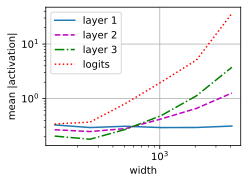

In [8]:
check_widths = [128, 256, 512, 1024, 2048, 4096]
sp_acts = coord_check(MLP, check_widths)
d2l.plot(check_widths, list(sp_acts), 'width', 'mean |activation|',
         xscale='log', yscale='log',
         legend=['layer 1', 'layer 2', 'layer 3', 'logits'])

The plot is the equation made visible. Layer 1, which
sits behind the fixed-fan-in input matrix, is flat. Layers 2 and 3, behind
the square matrices, grow with width — and the growth compounds with depth,
each layer feeding its excess to the next, so the logits fare worst of all:
they blow up by roughly two orders of magnitude across this range. A wide
enough network is thrown to divergence by the very first step at a learning
rate the narrow network finds comfortable. Now the same check under muP:

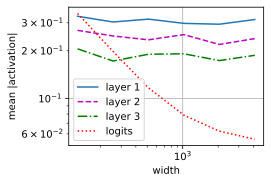

In [9]:
mup_acts = coord_check(MuMLP, check_widths)
d2l.plot(check_widths, list(mup_acts), 'width', 'mean |activation|',
         xscale='log', yscale='log',
         legend=['layer 1', 'layer 2', 'layer 3', 'logits'])

All three layer curves are flat: no layer's update scale depends on width
anymore. The logits curve *falls* with width rather than staying level, and
this is by design — the $1/m$ output multiplier starts the logits small,
and they grow to order one through learning (the coherent alignment of
the equation, now correctly budgeted) rather than through
size. Growth is the unambiguous failure; flat or falling says only that the
forward pass is stable, since the check reads activation sizes, not feature
learning — updates shrinking too fast would also read as falling, with the
layer quietly frozen. This
one-figure test catches the common muP implementation bugs — a missed
multiplier, a mislabeled layer, a framework default that snuck back in —
and the exercises use it exactly that way.

### Learning-Rate Transfer

The coordinate check verifies the mechanics. The payoff experiment is the
sweep of the previous section, rerun under muP:

width  128: best lr 7.8e-03
width  256: best lr 7.8e-03
width  512: best lr 7.8e-03
width 1024: best lr 7.8e-03


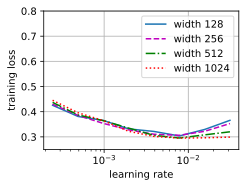

In [10]:
mup_loss = {w: [train_mlp(MuMLP, w, lr) for lr in lrs] for w in widths}
for w in widths:
    print(f'width {w:4d}: best lr {min(zip(mup_loss[w], lrs))[1]:.1e}')
d2l.plot(lrs, [mup_loss[w] for w in widths], 'learning rate',
         'training loss', xscale='log', ylim=[0.25, 0.8],
         legend=[f'width {w}' for w in widths])

The width-128 curve is identical to before, as it must be. The other three
no longer march left: under standard parametrization the optimum slid
steadily down, three grid steps across the eightfold change in width; under
muP it stops sliding — each width's optimum lands within a grid step or two
of the base model's, scatter rather than drift. Read off the transfer
directly: reuse the base width's best learning rate at width 1,024 and the
muP model lands within a couple of percent of the best loss any learning
rate achieves at that width; the standard-parametrization model misses its
own best by 15–20%.
This is *hyperparameter transfer*: tune the base model, scale up, keep the
numbers. Two caveats belong next to the result. On this small
family, retuning the wide model directly costs nothing, and standard
parametrization retuned at width 1,024 reaches a comparable loss — muP's
value is not a better optimum but not needing the sweep at the width where
sweeps are unaffordable. And transfer is a statement about the base
learning rate, not a warranty on every knob: schedules, batch size, and
regularization still interact with scale (that section). At
production scale the approach has real wins on the board:
@Yang.Hu.Babuschkin.ea.2022 tuned a 6.7-billion-parameter GPT-3 by
sweeping a 40-million-parameter proxy, spending about 7% of the pretraining
budget on tuning and outperforming the original model.

## The Spectral View

muP arrived through infinite-width limits, but there is a shorter road that
connects it to that section. There we measured an update by the right
norm for a matrix acting between spaces of different sizes; the healthy
scale for a layer mapping $n_{\text{in}}$ activations to $n_{\text{out}}$
is spectral norm on the order of $\sqrt{n_{\text{out}} / n_{\text{in}}}$,
for weights and updates alike:

$$
\|\mathbf{W}\|_2 \asymp \sqrt{\frac{n_{\text{out}}}{n_{\text{in}}}},
\qquad
\|\Delta\mathbf{W}\|_2 \asymp \sqrt{\frac{n_{\text{out}}}{n_{\text{in}}}}.
$$

@Yang.Simon.Bernstein.2023 show that this *spectral condition* is
equivalent to muP: the per-layer learning rates and multipliers of the table
above are exactly what it takes to make Adam's raw updates — whose spectral
norm grows with the layer's dimensions, as the equation
witnessed — land at the right spectral scale at every width. Seen this way,
muP is bookkeeping that repairs an optimizer which measures updates in the
wrong norm. An optimizer that measures them in the right norm needs less
repair: Muon orthogonalizes each hidden matrix's update and scales it per
shape [@Jordan.Jin.Boza.ea.2024; @Bernstein.Newhouse.2024], so much of
muP's per-layer control comes built in — though its RMS-matched scale is an
empirical convention, not the $\sqrt{n_{\text{out}} / n_{\text{in}}}$ of
the equation, a distinction that section already
flagged. This is one reason learning rates chosen
for Muon-family optimizers tend to survive width changes with less ceremony.

## What the Big Runs Do

Among production labs, "tune small, transfer big" is universal; the
mechanism is not. Cerebras adopted muP directly: the Cerebras-GPT family was
trained with hyperparameters transferred from a roughly 40-million-parameter
proxy, with the coordinate check as part of the release
[@Dey.Gosal.Chen.ea.2023]. DeepSeek took the empirical road instead:
rather than removing the drift, they measured it, fitting power laws for the
optimal learning rate and batch size as functions of the compute budget
across many small runs and extrapolating the fit to the target scale
[@Bi.Chen.Chen.ea.2024]. Meta reports training Llama 4 with an
in-house scheme called MetaP for setting per-layer learning rates and
initialization scales that transfer across width, depth, batch size, and
token budget — with methodology undisclosed [@Meta.2025]. And
Moonshot, training Kimi K2 with Muon over 15.5 trillion tokens, used no
width-dependent parametrization at all: they scale every layer's update to
a fixed root-mean-square size matched empirically to AdamW's typical update
[@Liu.Su.Yao.ea.2025; @Kimi.Team.2025] — per-layer control done by
measurement inside the optimizer, the spectral view's conclusion reached by
engineering rather than by limit theorems.

The theory itself is still moving. @Kosson.Welborn.Liu.ea.2025
present evidence that muP's assumptions describe only the first stretch of
training: in long runs with weight decay, update dynamics equilibrate to a
width-independent regime on their own, weight decay rather than
parametrization does the stabilizing, and muP's contribution resembles an
implicit warmup that a schedule could replace. Whether that account or the
spectral one better explains transfer in practice is an open question. The
practical reading for now: transfer is the shared goal, muP is one working
mechanism for it rather than settled law, and the coordinate check — cheap,
mechanical, unambiguous — is worth running on any model family you intend
to scale, whatever parametrization you choose.

## Summary

Hyperparameters tuned on a small model do not survive scaling by default:
the best learning rate drifts down as the network widens, because one Adam
step perturbs a hidden layer's activations in proportion to its fan-in
(the equation). The maximal update parametrization removes
the width dependence with per-layer rules — initialization variance
$\propto 1/\text{fan-in}$ as usual, hidden-matrix learning rates scaled by
$1/m$, logits scaled by $1/m$, inputs and biases left alone — after which
the optimum found at the base width holds across the family. The coordinate
check verifies any such scheme in seconds: mean activation sizes across
width must be flat after a training step. Spectrally, muP makes Adam's
updates land at the norm scale a layer's shape prescribes, much of which
Muon-style optimizers build in through their own shape-scaled updates.
Production practice
spans principled parametrization, fitted scaling laws, and empirically
matched update sizes; the goal of transfer is common to all of them.

## Exercises

1. Our coordinate check varies width at fixed depth. Generalize `MLP` from
   its three hidden layers to $L$ of them and run the check across
   $L \in \{3, 6, 12, 24\}$ at fixed width, under both parametrizations.
   Does muP's width scaling keep activations flat across depth? What does
   that tell you about what muP does and does not promise?
1. Verify transfer directly: under each parametrization, find the best
   learning rate at width 256 by sweeping, apply it unchanged at width
   1,024, and compare the loss against the best learning rate found by
   sweeping at width 1,024. Report all four optima.
1. Break muP on purpose: delete the $1/m$ logit scaling from `MuMLP` but
   keep the hidden learning-rate rule, and rerun the coordinate check.
   Which curve catches the bug? Repeat, this time keeping the multiplier
   but giving the hidden matrices the full learning rate.
1. Replace Adam with weight-decayed AdamW (that section) in the
   standard-parametrization sweep and train several times longer. Does the
   optimum drift less? Relate what you see to the argument of
   @Kosson.Welborn.Liu.ea.2025 that weight decay, not
   parametrization, stabilizes long runs.